In [74]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis_tools as au

# ============================================================
# USER SETTINGS — EDIT THESE
# ============================================================

# New Codex-selected working point
MU_WP  = 0.25   # <-- replace with new muIsoCut if different
EGM_WP = 0.10   # <-- replace with new egmIsoCut if different

# Base event-level cuts
DPHI_CUT = 2.0
MJJ_CUT = 150.0
PIXEL_CUT = 3

# Luminosity used in analysis_tools.py
LUMI = 59830.0

# Input directories
BACKGROUND_DIR = Path("./Updated-Background-JSONS")
SIGNAL_DIR = Path("./Updated-Signal-JSONS")
METADATA_PATH = Path("samples_metadata.pkl")

# Full 2D scan CSV from Codex
FULL_SCAN_CSV = Path("outputs/isoiso_abcd_working_point_scan_20260519_182024/full_2d_scan.csv")

# Optional: signal Asimov file from Codex
SIGNAL_ASIMOV_CSV = Path("outputs/isoiso_abcd_working_point_scan_20260519_182024/signal_asimov_significances.csv")

# Output directory for this notebook's plots
OUTDIR = Path("outputs/isoiso_wp_justification_notebook")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Plot settings
ISO_MIN = 0.0
ISO_MAX = 0.75

# Use coarser bins for independence plots to avoid sparse/noisy bins
N_BINS_INDEPENDENCE = 12

# Use finer bins only for visual density plots if desired
N_BINS_DENSITY = 25

print(f"Selected WP: muIsoCut={MU_WP}, egmIsoCut={EGM_WP}")
print(f"Base cuts: dPhi >= {DPHI_CUT}, mJJ >= {MJJ_CUT}, pixelCut <= {PIXEL_CUT}")
print(f"Output directory: {OUTDIR}")

Selected WP: muIsoCut=0.25, egmIsoCut=0.1
Base cuts: dPhi >= 2.0, mJJ >= 150.0, pixelCut <= 3
Output directory: outputs/isoiso_wp_justification_notebook


In [75]:
# Load background samples
backgrounds = au.load_samples(str(BACKGROUND_DIR))

print(f"Loaded {len(backgrounds)} background samples")
print("Keys in first background sample:")
print(backgrounds[0].keys())

# Load signal samples if metadata exists
signal = None

if METADATA_PATH.exists() and SIGNAL_DIR.exists():
    df_meta = pd.read_pickle(METADATA_PATH)
    sample_ids = df_meta.loc[
        (slice(None), slice(None), slice(None), slice(None)),
        "sample_id"
    ].values

    signal = au.load_samples(str(SIGNAL_DIR), sample_ids)
    print(f"Loaded {len(signal)} signal samples")
else:
    print("Signal metadata or signal directory not found. Skipping signal loading.")

Loaded 15 background samples
Keys in first background sample:
dict_keys(['dPhi', 'isolation', 'mJJ', 'egm_isolation', 'mu_lj_min_dxy', 'gen_weights', 'mu_lj_max_dxy', 'dsaMu_n', 'pfMu_n', 'pixelHits', 'trkHits', 'passing_weights', 'nevents', 'xsec'])
Loaded 48 signal samples


In [76]:
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    return np.sum(w[mask] * x[mask]) / np.sum(w[mask])


def weighted_cov(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    x = x[mask]
    y = y[mask]
    w = w[mask]

    mx = weighted_mean(x, w)
    my = weighted_mean(y, w)

    return np.sum(w * (x - mx) * (y - my)) / np.sum(w)


def weighted_corr(x, y, w):
    cov = weighted_cov(x, y, w)
    vx = weighted_cov(x, x, w)
    vy = weighted_cov(y, y, w)

    if not np.isfinite(cov) or not np.isfinite(vx) or not np.isfinite(vy):
        return np.nan

    if vx <= 0 or vy <= 0:
        return np.nan

    return cov / np.sqrt(vx * vy)


def weighted_spearman_like(x, y, w):
    """
    Weighted Pearson correlation of rank-transformed variables.
    This is a monotonic-correlation diagnostic.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    rx = pd.Series(x[mask]).rank(method="average").to_numpy(dtype=float)
    ry = pd.Series(y[mask]).rank(method="average").to_numpy(dtype=float)
    ww = w[mask]

    return weighted_corr(rx, ry, ww)


def safe_ratio(num, den):
    if den == 0 or not np.isfinite(den):
        return np.nan
    return num / den


def ratio_uncertainty(ratio, num, num_unc, den, den_unc):
    if (
        not np.isfinite(ratio)
        or not np.isfinite(num)
        or not np.isfinite(num_unc)
        or not np.isfinite(den)
        or not np.isfinite(den_unc)
        or num <= 0
        or den <= 0
    ):
        return np.nan

    return abs(ratio) * np.sqrt((num_unc / num) ** 2 + (den_unc / den) ** 2)


def asimov_significance(s, b):
    if b <= 0 or s < 0:
        return np.nan

    term = (s + b) * np.log(1 + s / b) - s

    if term <= 0:
        return 0.0

    return np.sqrt(2 * term)

In [77]:
def build_background_isoiso_table(backgrounds, dphi_cut=2.0, mjj_cut=150.0, pixel_cut=3):
    rows = []

    for i, sample in enumerate(backgrounds):
        required = [
            "isolation",
            "egm_isolation",
            "mJJ",
            "dPhi",
            "pixelHits",
            "pfMu_n",
            "dsaMu_n",
            "passing_weights",
            "xsec",
            "nevents",
        ]

        missing = [key for key in required if key not in sample]

        if missing:
            print(f"[warn] sample {i} missing required keys: {missing}")
            continue

        mu_iso = np.asarray(sample["isolation"], dtype=float)
        egm_iso = np.asarray(sample["egm_isolation"], dtype=float)
        mjj = np.asarray(sample["mJJ"], dtype=float)
        dphi = np.asarray(sample["dPhi"], dtype=float)

        pfmu_n = np.asarray(sample["pfMu_n"], dtype=float)
        dsamu_n = np.asarray(sample["dsaMu_n"], dtype=float)

        pixel_hits = np.asarray(sample["pixelHits"], dtype=object)
        pixel_hits = np.where(pixel_hits == None, np.nan, pixel_hits).astype(float)

        passing_weights = np.asarray(sample["passing_weights"], dtype=float)

        pixel_mask = np.where(np.isnan(pixel_hits), False, pixel_hits <= pixel_cut)

        displacement_mask = np.where(
            pfmu_n >= 1,
            pixel_mask,
            dsamu_n >= 1,
        )

        base_mask = (
            np.isfinite(mu_iso)
            & np.isfinite(egm_iso)
            & np.isfinite(mjj)
            & np.isfinite(dphi)
            & (dphi >= dphi_cut)
            & (mjj >= mjj_cut)
            & displacement_mask
        )

        scale = LUMI * float(sample.get("xsec", 0.0)) / float(sample.get("nevents", 1.0))
        event_weight = scale * passing_weights

        sample_name = sample.get("sample_name", f"background_{i}")

        temp = pd.DataFrame(
            {
                "sample_index": i,
                "sample_name": sample_name,
                "mu_iso": mu_iso[base_mask],
                "egm_iso": egm_iso[base_mask],
                "mJJ": mjj[base_mask],
                "dPhi": dphi[base_mask],
                "weight": event_weight[base_mask],
            }
        )

        rows.append(temp)

    if not rows:
        raise RuntimeError("No background events passed the base cuts.")

    return pd.concat(rows, ignore_index=True)

In [78]:
bkg_iso_df = build_background_isoiso_table(
    backgrounds,
    dphi_cut=DPHI_CUT,
    mjj_cut=MJJ_CUT,
    pixel_cut=PIXEL_CUT,
)

print(f"Rows after base cuts: {len(bkg_iso_df)}")
print(f"Weighted background yield after base cuts: {bkg_iso_df['weight'].sum():.3f}")

bkg_iso_df.head()

Rows after base cuts: 5104
Weighted background yield after base cuts: 5569.086


,sample_index,sample_name,mu_iso,egm_iso,mJJ,dPhi,weight
0,0,background_0,0.007443,1.020557,274.990644,2.134752,2.027297e-08
1,1,background_1,0.014952,0.960951,366.062387,3.108994,1.267735e-09
2,1,background_1,0.008993,0.498226,220.940327,2.832780,1.267735e-09
3,1,background_1,0.005403,0.573141,167.257789,2.999629,1.267735e-09
4,1,background_1,0.009259,0.123868,311.250670,2.769448,1.267735e-09


In [79]:
mu = bkg_iso_df["mu_iso"].to_numpy(dtype=float)
egm = bkg_iso_df["egm_iso"].to_numpy(dtype=float)
w = bkg_iso_df["weight"].to_numpy(dtype=float)

global_pearson = weighted_corr(mu, egm, w)
global_spearman = weighted_spearman_like(mu, egm, w)

# Local window around selected WP
local_window = 0.05

local_mask = (
    (bkg_iso_df["mu_iso"] >= MU_WP - local_window)
    & (bkg_iso_df["mu_iso"] <= MU_WP + local_window)
    & (bkg_iso_df["egm_iso"] >= EGM_WP - local_window)
    & (bkg_iso_df["egm_iso"] <= EGM_WP + local_window)
)

local_df = bkg_iso_df[local_mask].copy()

local_pearson = weighted_corr(
    local_df["mu_iso"].to_numpy(dtype=float),
    local_df["egm_iso"].to_numpy(dtype=float),
    local_df["weight"].to_numpy(dtype=float),
)

local_spearman = weighted_spearman_like(
    local_df["mu_iso"].to_numpy(dtype=float),
    local_df["egm_iso"].to_numpy(dtype=float),
    local_df["weight"].to_numpy(dtype=float),
)

corr_summary = pd.DataFrame(
    [
        {
            "region": "global_after_base_cuts",
            "weighted_pearson": global_pearson,
            "weighted_spearman_like": global_spearman,
            "n_rows": len(bkg_iso_df),
            "weighted_yield": bkg_iso_df["weight"].sum(),
        },
        {
            "region": f"local_window_pm_{local_window}",
            "weighted_pearson": local_pearson,
            "weighted_spearman_like": local_spearman,
            "n_rows": len(local_df),
            "weighted_yield": local_df["weight"].sum(),
        },
    ]
)

corr_summary.to_csv(OUTDIR / "correlation_summary.csv", index=False)
corr_summary

,region,weighted_pearson,weighted_spearman_like,n_rows,weighted_yield
0,global_after_base_cuts,-0.069780,-0.074383,5104,5569.086469
1,local_window_pm_0.05,-0.319232,-0.058544,27,40.490693


In [80]:
def compute_isoiso_abcd_counts_from_events(df, mu_cut, egm_cut):
    mu_pass = df["mu_iso"].to_numpy(dtype=float) <= mu_cut
    egm_pass = df["egm_iso"].to_numpy(dtype=float) <= egm_cut
    weights = df["weight"].to_numpy(dtype=float)

    masks = {
        "A": mu_pass & egm_pass,
        "B": (~mu_pass) & egm_pass,
        "C": mu_pass & (~egm_pass),
        "D": (~mu_pass) & (~egm_pass),
    }

    out = {}

    for region, mask in masks.items():
        out[f"{region}"] = float(np.sum(weights[mask]))
        out[f"{region}_unc"] = float(np.sqrt(np.sum(weights[mask] ** 2)))

    A = out["A"]
    B = out["B"]
    C = out["C"]
    D = out["D"]

    A_unc = out["A_unc"]
    B_unc = out["B_unc"]
    C_unc = out["C_unc"]
    D_unc = out["D_unc"]

    if B > 0 and C > 0 and D > 0:
        prediction = B * C / D
        prediction_unc = prediction * np.sqrt(
            (B_unc / B) ** 2
            + (C_unc / C) ** 2
            + (D_unc / D) ** 2
        )
    else:
        prediction = np.nan
        prediction_unc = np.nan

    if A > 0 and np.isfinite(prediction):
        closure = 1.0 - prediction / A
        closure_unc = (prediction / A) * np.sqrt(
            (B_unc / B) ** 2
            + (C_unc / C) ** 2
            + (D_unc / D) ** 2
            + (A_unc / A) ** 2
        )
    else:
        closure = np.nan
        closure_unc = np.nan

    if np.isfinite(prediction_unc):
        closure_sig = (A - prediction) / np.sqrt(A_unc**2 + prediction_unc**2)
    else:
        closure_sig = np.nan

    tf_AC = safe_ratio(A, C)
    tf_BD = safe_ratio(B, D)
    tf_ratio = safe_ratio(tf_AC, tf_BD)

    tf_AC_unc = ratio_uncertainty(tf_AC, A, A_unc, C, C_unc)
    tf_BD_unc = ratio_uncertainty(tf_BD, B, B_unc, D, D_unc)

    out["prediction"] = prediction
    out["prediction_unc"] = prediction_unc
    out["closure"] = closure
    out["closure_unc"] = closure_unc
    out["closure_significance"] = closure_sig
    out["tf_AC"] = tf_AC
    out["tf_AC_unc"] = tf_AC_unc
    out["tf_BD"] = tf_BD
    out["tf_BD_unc"] = tf_BD_unc
    out["tf_ratio"] = tf_ratio

    return out

In [81]:
abcd_wp = compute_isoiso_abcd_counts_from_events(
    bkg_iso_df,
    mu_cut=MU_WP,
    egm_cut=EGM_WP,
)

abcd_summary = pd.DataFrame([abcd_wp])
abcd_summary.insert(0, "muIsoCut", MU_WP)
abcd_summary.insert(1, "egmIsoCut", EGM_WP)
abcd_summary.insert(2, "dPhiCut", DPHI_CUT)
abcd_summary.insert(3, "mJJCut", MJJ_CUT)
abcd_summary.insert(4, "pixelCut", PIXEL_CUT)

abcd_summary.to_csv(OUTDIR / "abcd_summary_selected_wp.csv", index=False)
abcd_summary.T

,0
muIsoCut,0.250000
egmIsoCut,0.100000
dPhiCut,2.000000
mJJCut,150.000000
pixelCut,3.000000
A,126.930609
A_unc,39.461361
B,459.174739
B_unc,74.918337
C,1060.583791


In [82]:
closure = abcd_wp["closure"]
closure_unc = abcd_wp["closure_unc"]

central_pass = abs(closure) <= 0.1
two_sigma_overlap = (closure - 2 * closure_unc <= 0.1) and (closure + 2 * closure_unc >= -0.1)

print(f"closure = {closure:.4f} ± {closure_unc:.4f}")
print(f"Central value within ±0.1? {central_pass}")
print(f"2σ interval overlaps [-0.1, 0.1]? {two_sigma_overlap}")

if central_pass:
    print("Conclusion: closure central value is inside the target ±0.1 band.")
elif two_sigma_overlap:
    print("Conclusion: closure is compatible with the target band within 2σ.")
else:
    print("Conclusion: closure is NOT compatible with the target criterion.")

closure = 0.0219 ± 0.4257
Central value within ±0.1? True
2σ interval overlaps [-0.1, 0.1]? True
Conclusion: closure central value is inside the target ±0.1 band.


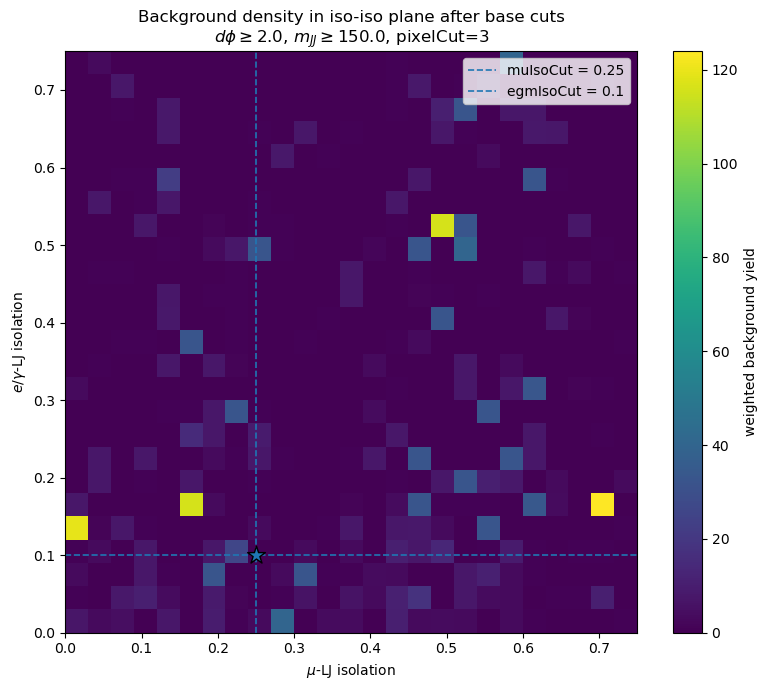

In [83]:
bins_density = np.linspace(ISO_MIN, ISO_MAX, N_BINS_DENSITY + 1)

h_density, xedges_density, yedges_density = np.histogram2d(
    bkg_iso_df["mu_iso"],
    bkg_iso_df["egm_iso"],
    bins=[bins_density, bins_density],
    weights=bkg_iso_df["weight"],
)

fig, ax = plt.subplots(figsize=(8, 7))

mesh = ax.pcolormesh(xedges_density, yedges_density, h_density.T, shading="auto")
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("weighted background yield")

ax.axvline(MU_WP, linestyle="--", linewidth=1.2, label=f"muIsoCut = {MU_WP}")
ax.axhline(EGM_WP, linestyle="--", linewidth=1.2, label=f"egmIsoCut = {EGM_WP}")
ax.scatter([MU_WP], [EGM_WP], marker="*", s=180, edgecolor="black", zorder=5)

ax.set_xlabel(r"$\mu$-LJ isolation")
ax.set_ylabel(r"$e/\gamma$-LJ isolation")
ax.set_title(
    "Background density in iso-iso plane after base cuts\n"
    rf"$d\phi \geq {DPHI_CUT}$, $m_{{JJ}} \geq {MJJ_CUT}$, pixelCut={PIXEL_CUT}"
)
ax.legend()

fig.tight_layout()
fig.savefig(OUTDIR / "background_density_isoiso.png", dpi=300)
fig.savefig(OUTDIR / "background_density_isoiso.pdf")
plt.show()

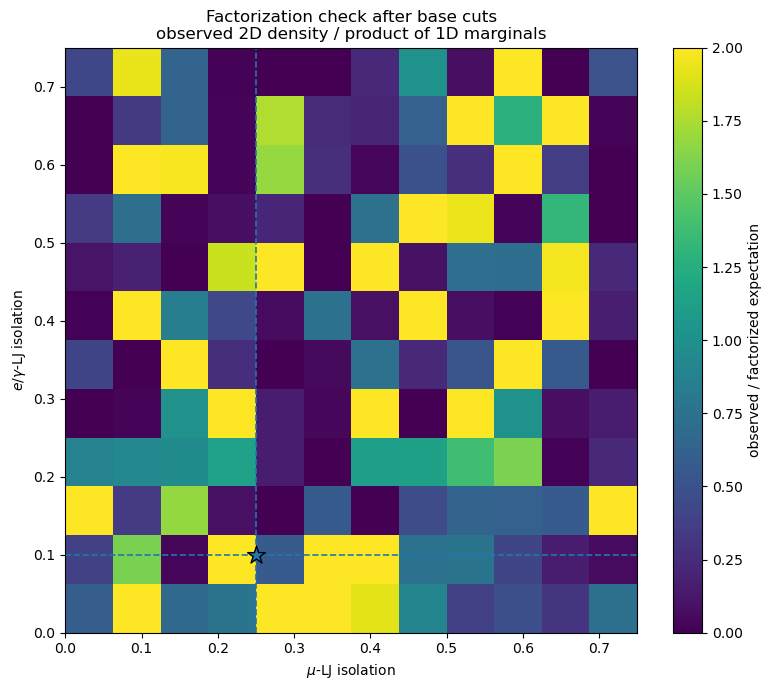

In [84]:
bins_ind = np.linspace(ISO_MIN, ISO_MAX, N_BINS_INDEPENDENCE + 1)

h, xedges, yedges = np.histogram2d(
    bkg_iso_df["mu_iso"],
    bkg_iso_df["egm_iso"],
    bins=[bins_ind, bins_ind],
    weights=bkg_iso_df["weight"],
)

total = np.sum(h)
x_marg = np.sum(h, axis=1)
y_marg = np.sum(h, axis=0)

expected = np.outer(x_marg, y_marg) / total if total > 0 else np.full_like(h, np.nan)

factorization_ratio = np.full_like(h, np.nan, dtype=float)
mask = expected > 1e-8
factorization_ratio[mask] = h[mask] / expected[mask]

fig, ax = plt.subplots(figsize=(8, 7))

mesh = ax.pcolormesh(
    xedges,
    yedges,
    factorization_ratio.T,
    shading="auto",
    vmin=0.0,
    vmax=2.0,
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("observed / factorized expectation")

ax.axvline(MU_WP, linestyle="--", linewidth=1.2)
ax.axhline(EGM_WP, linestyle="--", linewidth=1.2)
ax.scatter([MU_WP], [EGM_WP], marker="*", s=180, edgecolor="black", zorder=5)

ax.set_xlabel(r"$\mu$-LJ isolation")
ax.set_ylabel(r"$e/\gamma$-LJ isolation")
ax.set_title(
    "Factorization check after base cuts\n"
    "observed 2D density / product of 1D marginals"
)

fig.tight_layout()
fig.savefig(OUTDIR / "factorization_ratio_isoiso_coarse.png", dpi=300)
fig.savefig(OUTDIR / "factorization_ratio_isoiso_coarse.pdf")
plt.show()

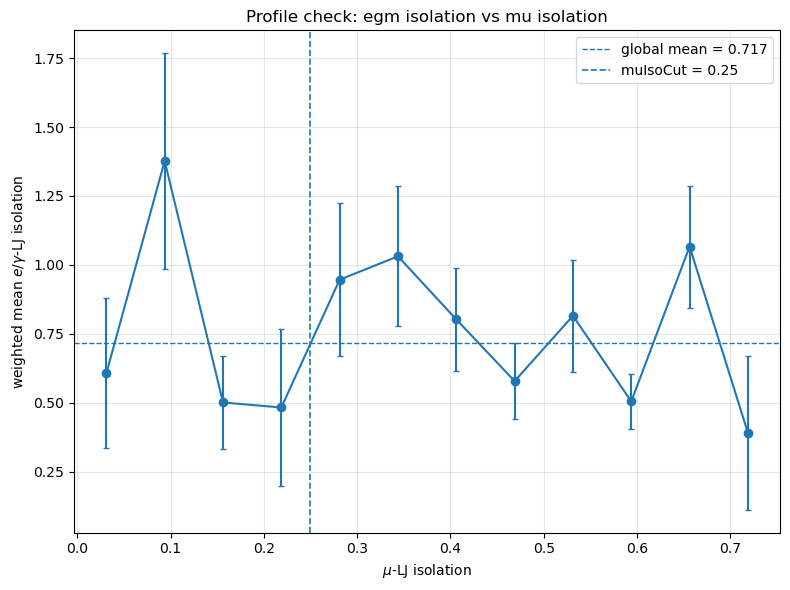

In [85]:
bins = np.linspace(ISO_MIN, ISO_MAX, N_BINS_INDEPENDENCE + 1)
centers = 0.5 * (bins[:-1] + bins[1:])

profile_mean = []
profile_err = []

global_mean_egm = weighted_mean(egm, w)

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (mu >= lo) & (mu < hi) & np.isfinite(egm) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        profile_mean.append(np.nan)
        profile_err.append(np.nan)
        continue

    yy = egm[mask]
    ww = w[mask]

    mean = weighted_mean(yy, ww)
    var = weighted_mean((yy - mean) ** 2, ww)

    neff = (np.sum(ww) ** 2) / np.sum(ww**2) if np.sum(ww**2) > 0 else np.nan
    err = np.sqrt(var / neff) if neff > 0 else np.nan

    profile_mean.append(mean)
    profile_err.append(err)

profile_mean = np.asarray(profile_mean)
profile_err = np.asarray(profile_err)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.isfinite(profile_mean) & np.isfinite(profile_err)

ax.errorbar(
    centers[mask],
    profile_mean[mask],
    yerr=profile_err[mask],
    marker="o",
    linestyle="-",
    capsize=2,
)

ax.axhline(global_mean_egm, linestyle="--", linewidth=1.0, label=f"global mean = {global_mean_egm:.3f}")
ax.axvline(MU_WP, linestyle="--", linewidth=1.2, label=f"muIsoCut = {MU_WP}")

ax.set_xlabel(r"$\mu$-LJ isolation")
ax.set_ylabel(r"weighted mean $e/\gamma$-LJ isolation")
ax.set_title("Profile check: egm isolation vs mu isolation")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTDIR / "profile_egmIso_vs_muIso.png", dpi=300)
fig.savefig(OUTDIR / "profile_egmIso_vs_muIso.pdf")
plt.show()

In [86]:
egm_pass_given_mu = []
mu_pass_given_egm = []

for lo, hi in zip(bins[:-1], bins[1:]):
    mu_bin = (mu >= lo) & (mu < hi) & np.isfinite(w) & (w > 0)
    egm_bin = (egm >= lo) & (egm < hi) & np.isfinite(w) & (w > 0)

    if np.sum(w[mu_bin]) > 0:
        egm_pass_given_mu.append(
            np.sum(w[mu_bin & (egm <= EGM_WP)]) / np.sum(w[mu_bin])
        )
    else:
        egm_pass_given_mu.append(np.nan)

    if np.sum(w[egm_bin]) > 0:
        mu_pass_given_egm.append(
            np.sum(w[egm_bin & (mu <= MU_WP)]) / np.sum(w[egm_bin])
        )
    else:
        mu_pass_given_egm.append(np.nan)

egm_pass_given_mu = np.asarray(egm_pass_given_mu)
mu_pass_given_egm = np.asarray(mu_pass_given_egm)

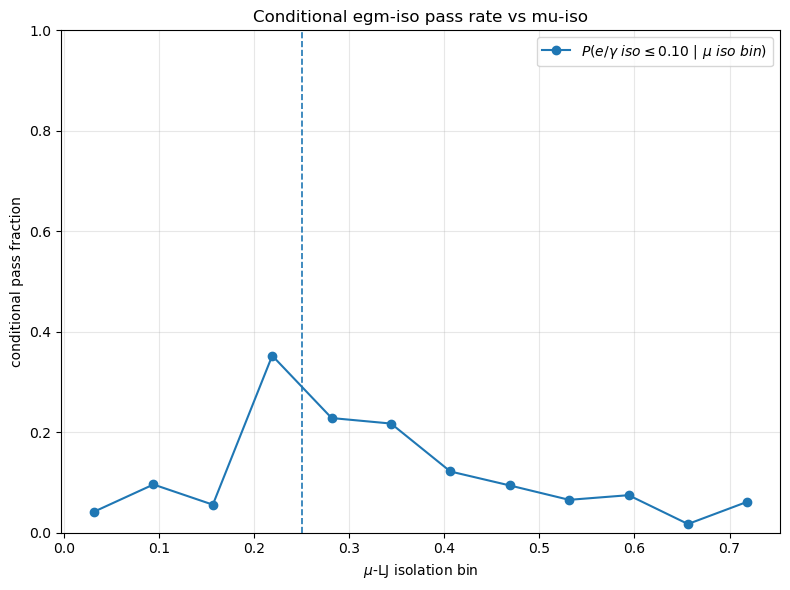

In [87]:
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.isfinite(egm_pass_given_mu)

ax.plot(
    centers[mask],
    egm_pass_given_mu[mask],
    marker="o",
    linestyle="-",
    label=rf"$P(e/\gamma\ iso \leq {EGM_WP:.2f}\ |\ \mu\ iso\ bin)$",
)

ax.axvline(MU_WP, linestyle="--", linewidth=1.2)
ax.set_xlabel(r"$\mu$-LJ isolation bin")
ax.set_ylabel("conditional pass fraction")
ax.set_ylim(0, 1)
ax.set_title("Conditional egm-iso pass rate vs mu-iso")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTDIR / "conditional_egm_pass_given_mu_bin.png", dpi=300)
fig.savefig(OUTDIR / "conditional_egm_pass_given_mu_bin.pdf")
plt.show()

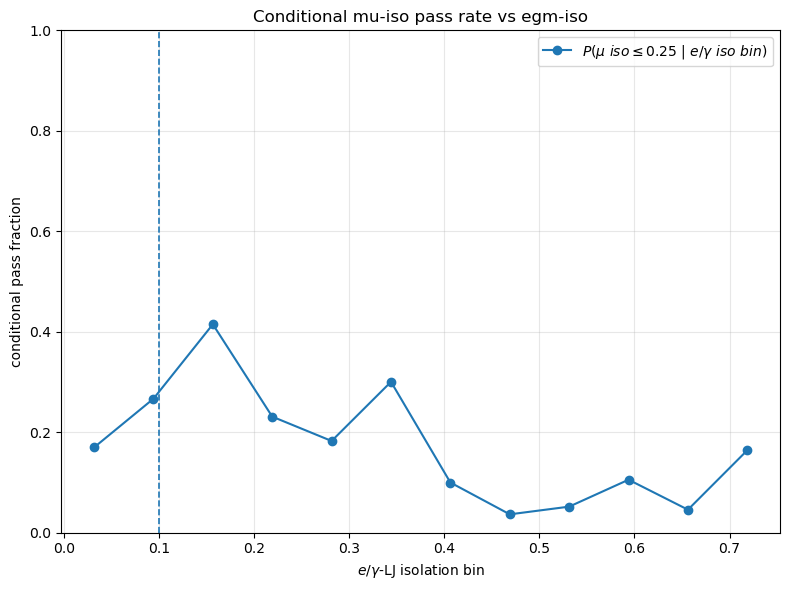

In [88]:
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.isfinite(mu_pass_given_egm)

ax.plot(
    centers[mask],
    mu_pass_given_egm[mask],
    marker="o",
    linestyle="-",
    label=rf"$P(\mu\ iso \leq {MU_WP:.2f}\ |\ e/\gamma\ iso\ bin)$",
)

ax.axvline(EGM_WP, linestyle="--", linewidth=1.2)
ax.set_xlabel(r"$e/\gamma$-LJ isolation bin")
ax.set_ylabel("conditional pass fraction")
ax.set_ylim(0, 1)
ax.set_title("Conditional mu-iso pass rate vs egm-iso")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTDIR / "conditional_mu_pass_given_egm_bin.png", dpi=300)
fig.savefig(OUTDIR / "conditional_mu_pass_given_egm_bin.pdf")
plt.show()

In [89]:
if FULL_SCAN_CSV.exists():
    scan_df = pd.read_csv(FULL_SCAN_CSV)
    print(f"Loaded scan CSV: {FULL_SCAN_CSV}")
    print(scan_df.shape)
    display(scan_df.head())
else:
    scan_df = None
    print(f"Full scan CSV not found: {FULL_SCAN_CSV}")

Loaded scan CSV: outputs/isoiso_abcd_working_point_scan_20260519_182024/full_2d_scan.csv
(64, 98)


,ACounts,A_Unc,QCD_ACounts,QCDA_Unc,TTJets_ACounts,TTJetsA_Unc,DY_ACounts,DYA_Unc,BCounts,B_Unc,...,target_a_pass,sideband_min_pass,candidate_range_pass,edge_margin_pass,closure_significance_pass,neighbor_count_pass,local_stability_pass,no_zero_denominator_status,candidate_filter_status,candidate_hard_pass
0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,2.187379,1.152137,...,False,False,False,False,False,False,False,False,"fail:status,finite_values,target_a,sideband_mi...",False
1,0.002601,0.002601,0.002601,0.002601,0.0,0.0,0.000000e+00,0.000000e+00,653.690655,91.828339,...,False,False,False,False,True,False,False,True,"fail:target_a,sideband_min,candidate_range,nei...",False
2,0.002601,0.002601,0.002601,0.002601,0.0,0.0,0.000000e+00,0.000000e+00,1439.880808,234.138985,...,False,False,False,False,True,True,True,True,"fail:target_a,sideband_min,candidate_range",False
3,0.002601,0.002601,0.002601,0.002601,0.0,0.0,1.267735e-09,1.267735e-09,1907.081121,271.774571,...,False,False,False,False,True,True,True,True,"fail:target_a,sideband_min,candidate_range",False
4,0.002601,0.002601,0.002601,0.002601,0.0,0.0,1.267735e-09,1.267735e-09,2228.700867,284.489105,...,False,False,False,False,True,True,True,True,"fail:target_a,sideband_min,candidate_range",False


In [90]:
if scan_df is not None:
    if "tf_closure_ratio" not in scan_df.columns:
        if "tf_AC" in scan_df.columns and "tf_BD" in scan_df.columns:
            scan_df["tf_closure_ratio"] = scan_df["tf_AC"] / scan_df["tf_BD"]

    # Add closure compatibility flag
    if "closure_compatible" not in scan_df.columns and {"closure", "closureUnc"}.issubset(scan_df.columns):
        scan_df["closure_compatible"] = (
            (scan_df["closure"].abs() <= 0.1)
            | (
                (scan_df["closure"] - 2 * scan_df["closureUnc"] <= 0.1)
                & (scan_df["closure"] + 2 * scan_df["closureUnc"] >= -0.1)
            )
        )

    scan_df.head()

In [91]:
def plot_scan_heatmap(scan_df, value_col, title, cbar_label, vmin=None, vmax=None, outname=None):
    if value_col not in scan_df.columns:
        print(f"Column {value_col} not found. Skipping.")
        return

    pivot = (
        scan_df
        .pivot_table(index="egmIsoCut", columns="muIsoCut", values=value_col, aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )

    x = pivot.columns.to_numpy(dtype=float)
    y = pivot.index.to_numpy(dtype=float)
    z = pivot.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 7))

    mesh = ax.pcolormesh(x, y, z, shading="auto", vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)

    # Add A-count contours if possible
    if "ACounts" in scan_df.columns:
        a_pivot = (
            scan_df
            .pivot_table(index="egmIsoCut", columns="muIsoCut", values="ACounts", aggfunc="mean")
            .sort_index()
            .sort_index(axis=1)
        )

        a_z = a_pivot.to_numpy(dtype=float)

        try:
            cs = ax.contour(x, y, a_z, levels=[50, 100, 200], linewidths=1.0)
            ax.clabel(cs, inline=True, fontsize=8, fmt="A=%.0f")
        except Exception as exc:
            print(f"Could not draw A-count contours: {exc}")

    ax.axvline(MU_WP, linestyle="--", linewidth=1.2)
    ax.axhline(EGM_WP, linestyle="--", linewidth=1.2)
    ax.scatter([MU_WP], [EGM_WP], marker="*", s=180, edgecolor="black", zorder=5)

    ax.set_xlabel(r"$\mu$-LJ isolation cut")
    ax.set_ylabel(r"$e/\gamma$-LJ isolation cut")
    ax.set_title(title)

    fig.tight_layout()

    if outname is not None:
        fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
        fig.savefig(OUTDIR / f"{outname}.pdf")

    plt.show()

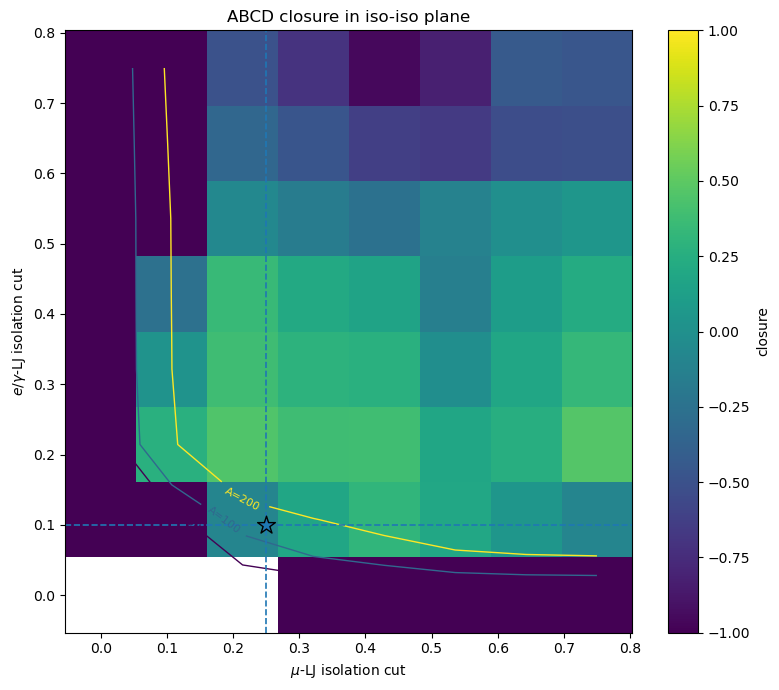

In [92]:
if scan_df is not None:
    plot_scan_heatmap(
        scan_df,
        value_col="closure",
        title="ABCD closure in iso-iso plane",
        cbar_label="closure",
        vmin=-1,
        vmax=1,
        outname="scan_heatmap_closure",
    )

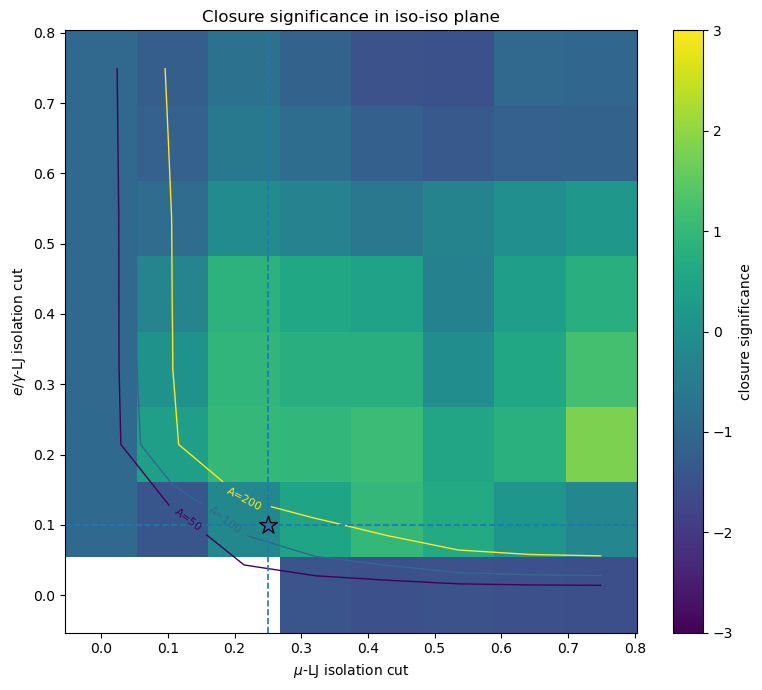

In [93]:
if scan_df is not None:
    plot_scan_heatmap(
        scan_df,
        value_col="closureSignificance",
        title="Closure significance in iso-iso plane",
        cbar_label="closure significance",
        vmin=-3,
        vmax=3,
        outname="scan_heatmap_closure_significance",
    )

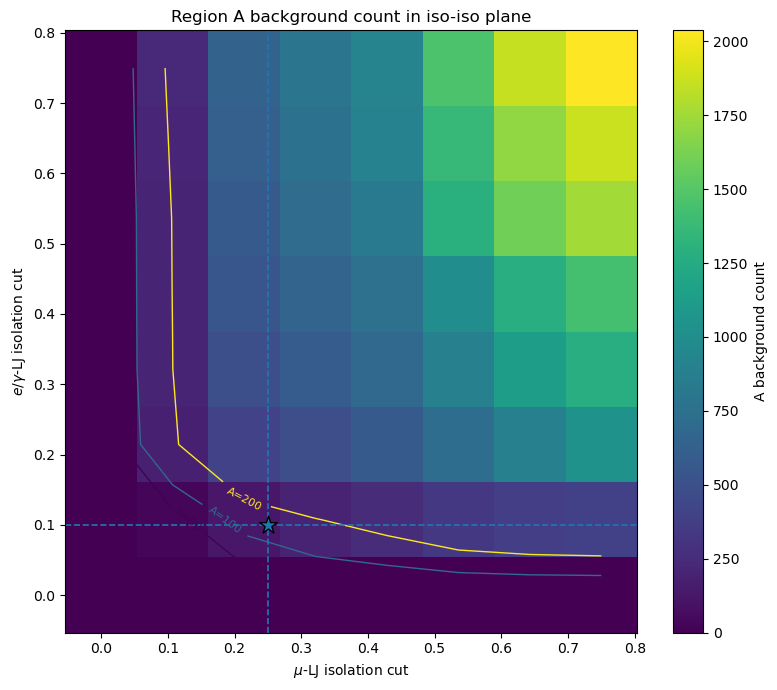

In [94]:
if scan_df is not None:
    plot_scan_heatmap(
        scan_df,
        value_col="ACounts",
        title="Region A background count in iso-iso plane",
        cbar_label="A background count",
        outname="scan_heatmap_A_counts",
    )

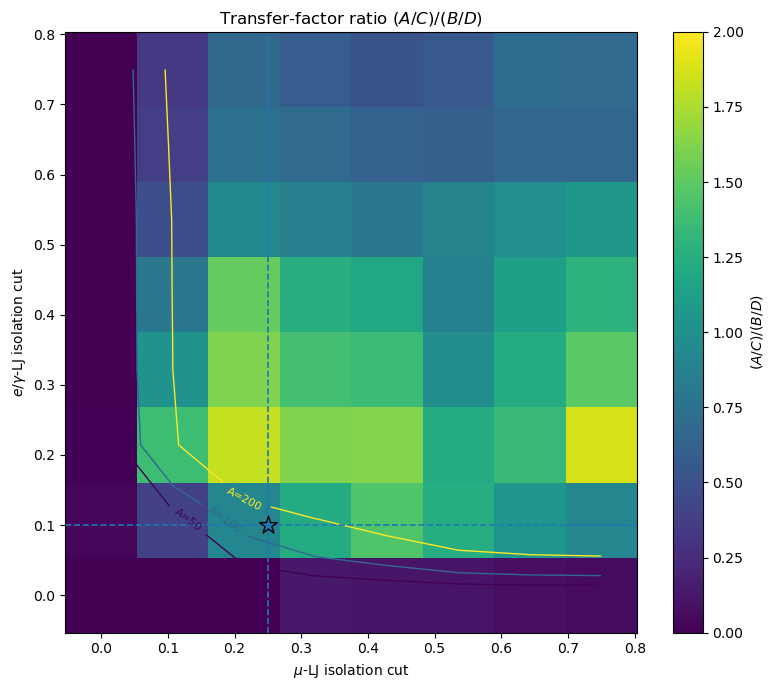

In [95]:
if scan_df is not None:
    plot_scan_heatmap(
        scan_df,
        value_col="tf_closure_ratio",
        title=r"Transfer-factor ratio $(A/C)/(B/D)$",
        cbar_label=r"$(A/C)/(B/D)$",
        vmin=0,
        vmax=2,
        outname="scan_heatmap_transfer_factor_ratio",
    )

In [96]:
if scan_df is not None and "stability_score" in scan_df.columns:
    plot_scan_heatmap(
        scan_df,
        value_col="stability_score",
        title="Candidate stability score in iso-iso plane",
        cbar_label="stability score",
        outname="scan_heatmap_stability_score",
    )

In [97]:
def nearest_value(values, target):
    values = np.asarray(sorted(np.unique(values)), dtype=float)
    return float(values[np.argmin(np.abs(values - target))])


def add_errorbar(ax, x, y, yerr=None, label=None, marker="o", linestyle="-"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
        mask = mask & np.isfinite(yerr)
        ax.errorbar(
            x[mask],
            y[mask],
            yerr=yerr[mask],
            label=label,
            marker=marker,
            linestyle=linestyle,
            capsize=2,
        )
    else:
        ax.plot(x[mask], y[mask], label=label, marker=marker, linestyle=linestyle)


def plot_three_panel_slice(
    scan_df,
    scan_axis,
    fixed_axis,
    fixed_value,
    selected_value,
    title,
    outname,
    closure_ylim=(-2, 2),
    tf_ylim=(0, 5),
    log_counts=False,
):
    actual_fixed = nearest_value(scan_df[fixed_axis].to_numpy(), fixed_value)

    sl = scan_df[np.isclose(scan_df[fixed_axis], actual_fixed)].copy()
    sl = sl.sort_values(scan_axis)

    x = sl[scan_axis].to_numpy(dtype=float)

    fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)

    # Top: closure
    add_errorbar(
        axes[0],
        x,
        sl["closure"].to_numpy(dtype=float),
        sl["closureUnc"].to_numpy(dtype=float) if "closureUnc" in sl.columns else None,
        label="closure",
    )

    axes[0].axhline(0.0, linestyle="--", linewidth=1.0)
    axes[0].axhline(0.1, linestyle=":", linewidth=1.0)
    axes[0].axhline(-0.1, linestyle=":", linewidth=1.0)
    axes[0].axvline(selected_value, linestyle="--", linewidth=1.2)
    axes[0].set_ylabel("closure")
    axes[0].set_ylim(*closure_ylim)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Middle: transfer factors
    add_errorbar(
        axes[1],
        x,
        sl["tf_AC"].to_numpy(dtype=float),
        sl["tf_AC_unc"].to_numpy(dtype=float) if "tf_AC_unc" in sl.columns else None,
        label="A/C",
    )

    add_errorbar(
        axes[1],
        x,
        sl["tf_BD"].to_numpy(dtype=float),
        sl["tf_BD_unc"].to_numpy(dtype=float) if "tf_BD_unc" in sl.columns else None,
        label="B/D",
    )

    axes[1].axvline(selected_value, linestyle="--", linewidth=1.2)
    axes[1].set_ylabel("transfer factor")
    axes[1].set_ylim(*tf_ylim)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Bottom: A/B/C/D counts
    for region in ["A", "B", "C", "D"]:
        count_col = f"{region}Counts"
        unc_col = f"{region}_Unc"

        if count_col in sl.columns:
            add_errorbar(
                axes[2],
                x,
                sl[count_col].to_numpy(dtype=float),
                sl[unc_col].to_numpy(dtype=float) if unc_col in sl.columns else None,
                label=region,
            )

    axes[2].axvline(selected_value, linestyle="--", linewidth=1.2)
    axes[2].set_ylabel("background count")

    if scan_axis == "muIsoCut":
        axes[2].set_xlabel(r"$\mu$-LJ isolation cut")
    else:
        axes[2].set_xlabel(r"$e/\gamma$-LJ isolation cut")

    if log_counts:
        axes[2].set_yscale("log")

    axes[2].legend(ncol=4)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

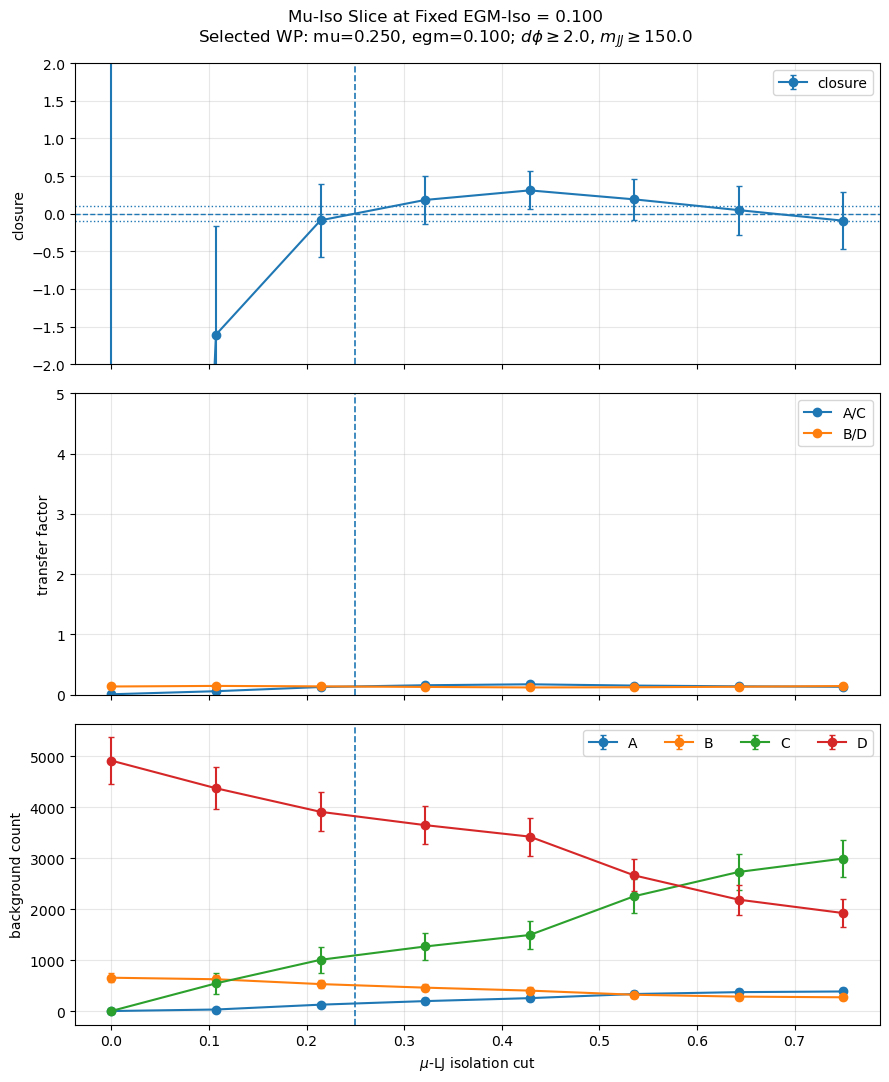

In [98]:
if scan_df is not None:
    plot_three_panel_slice(
        scan_df,
        scan_axis="muIsoCut",
        fixed_axis="egmIsoCut",
        fixed_value=EGM_WP,
        selected_value=MU_WP,
        title=(
            rf"Mu-Iso Slice at Fixed EGM-Iso = {EGM_WP:.3f}"
            "\n"
            rf"Selected WP: mu={MU_WP:.3f}, egm={EGM_WP:.3f}; "
            rf"$d\phi \geq {DPHI_CUT}$, $m_{{JJ}} \geq {MJJ_CUT}$"
        ),
        outname="three_panel_muIso_scan_fixed_egmIso",
        closure_ylim=(-2, 2),
        tf_ylim=(0, 5),
        log_counts=False,
    )

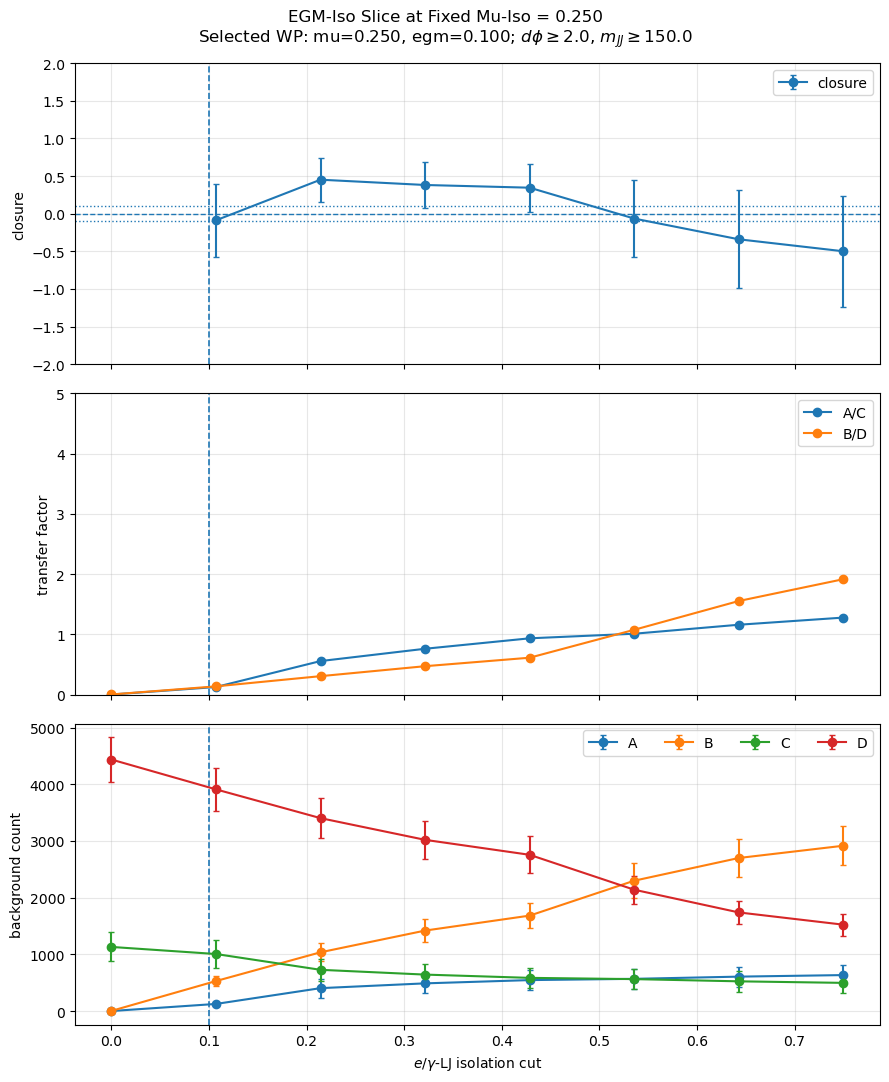

In [99]:
if scan_df is not None:
    plot_three_panel_slice(
        scan_df,
        scan_axis="egmIsoCut",
        fixed_axis="muIsoCut",
        fixed_value=MU_WP,
        selected_value=EGM_WP,
        title=(
            rf"EGM-Iso Slice at Fixed Mu-Iso = {MU_WP:.3f}"
            "\n"
            rf"Selected WP: mu={MU_WP:.3f}, egm={EGM_WP:.3f}; "
            rf"$d\phi \geq {DPHI_CUT}$, $m_{{JJ}} \geq {MJJ_CUT}$"
        ),
        outname="three_panel_egmIso_scan_fixed_muIso",
        closure_ylim=(-2, 2),
        tf_ylim=(0, 5),
        log_counts=False,
    )

In [100]:
def local_zoom_scan(scan_df, mu_wp, egm_wp, window=0.05):
    return scan_df[
        (scan_df["muIsoCut"] >= mu_wp - window)
        & (scan_df["muIsoCut"] <= mu_wp + window)
        & (scan_df["egmIsoCut"] >= egm_wp - window)
        & (scan_df["egmIsoCut"] <= egm_wp + window)
    ].copy()

In [101]:
if scan_df is not None:
    local_scan = local_zoom_scan(scan_df, MU_WP, EGM_WP, window=0.05)

    print(local_scan.shape)
    display(local_scan.head())

(1, 98)


,ACounts,A_Unc,QCD_ACounts,QCDA_Unc,TTJets_ACounts,TTJetsA_Unc,DY_ACounts,DYA_Unc,BCounts,B_Unc,...,target_a_pass,sideband_min_pass,candidate_range_pass,edge_margin_pass,closure_significance_pass,neighbor_count_pass,local_stability_pass,no_zero_denominator_status,candidate_filter_status,candidate_hard_pass
17,124.993725,39.444776,91.322904,38.115935,33.670821,10.152135,4.563845e-08,7.814841e-09,528.699531,82.924987,...,True,True,True,False,True,True,True,True,pass,True


Could not draw A-count contours: Input z must be at least a (2, 2) shaped array, but has shape (1, 1)


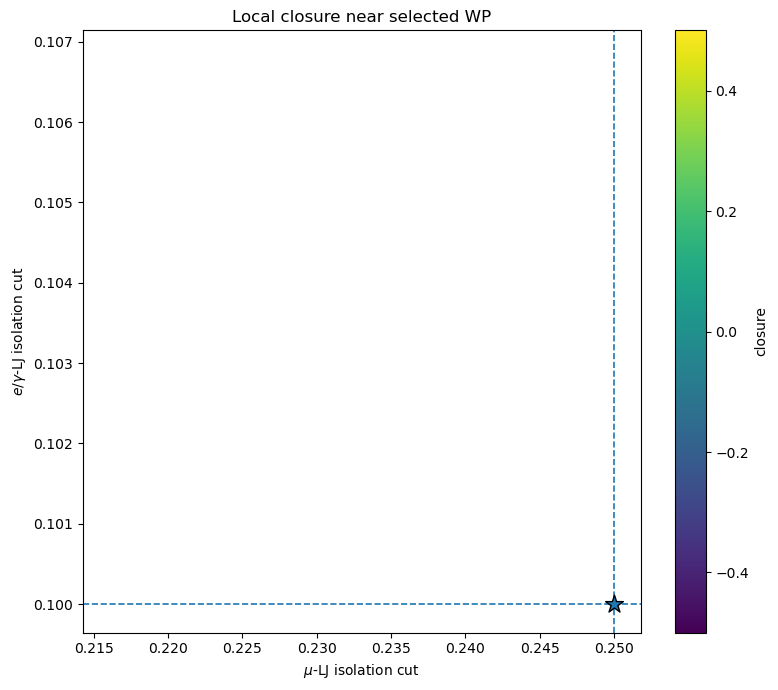

In [102]:
if scan_df is not None and len(local_scan) > 0:
    plot_scan_heatmap(
        local_scan,
        value_col="closure",
        title="Local closure near selected WP",
        cbar_label="closure",
        vmin=-0.5,
        vmax=0.5,
        outname="local_zoom_closure",
    )

In [103]:
candidate_paths = [
    OUTDIR.parent / "candidate_working_points_independence_reranked.csv",
    OUTDIR.parent / "candidate_working_points_reranked.csv",
    OUTDIR.parent / "candidate_working_points.csv",
]

candidate_df = None

for p in candidate_paths:
    if p.exists():
        candidate_df = pd.read_csv(p)
        print(f"Loaded candidates from {p}")
        break

if candidate_df is not None:
    cols_to_show = [
        c for c in [
            "muIsoCut",
            "egmIsoCut",
            "stability_score",
            "independence_score",
            "ACounts",
            "A_Unc",
            "closure",
            "closureUnc",
            "closureSignificance",
            "tf_AC",
            "tf_BD",
            "tf_closure_ratio",
            "local_pearson",
            "local_spearman",
        ]
        if c in candidate_df.columns
    ]

    display(candidate_df[cols_to_show].head(10))
else:
    print("No candidate file found.")

No candidate file found.


In [104]:
candidate_paths

[PosixPath('outputs/candidate_working_points_independence_reranked.csv'),
 PosixPath('outputs/candidate_working_points_reranked.csv'),
 PosixPath('outputs/candidate_working_points.csv')]

In [105]:
if SIGNAL_ASIMOV_CSV.exists():
    sig_df = pd.read_csv(SIGNAL_ASIMOV_CSV)
    print(f"Loaded signal Asimov file: {SIGNAL_ASIMOV_CSV}")
    display(sig_df.head())
else:
    sig_df = None
    print(f"Signal Asimov file not found: {SIGNAL_ASIMOV_CSV}")

Loaded signal Asimov file: outputs/isoiso_abcd_working_point_scan_20260519_182024/signal_asimov_significances.csv


,candidate_rank,sample_index,sample_name,muIsoCut,egmIsoCut,S_A,S_A_Unc,B_A,B_A_Unc,AsimovSig,signalEff,S_B,S_C,S_D
0,1,0,2Mu2E_200GeV_0p25GeV_0p1mm_info,0.214286,0.107143,12.747070,0.631074,124.993725,39.444776,1.121562,0.769811,0.124971,3.592924,0.093728
1,1,1,2Mu2E_200GeV_1p2GeV_0p48mm_info,0.214286,0.107143,5.964815,0.465774,124.993725,39.444776,0.529361,0.742081,0.181854,1.854912,0.036371
2,1,2,2Mu2E_200GeV_5p0GeV_2p0mm_info,0.214286,0.107143,5.265936,0.443472,124.993725,39.444776,0.467761,0.746032,0.112041,1.643271,0.037347
3,1,3,2Mu2E_500GeV_0p25GeV_0p04mm_info,0.214286,0.107143,15.063445,0.439820,124.993725,39.444776,1.321562,0.899540,0.064209,1.605226,0.012842
4,1,4,2Mu2E_500GeV_1p2GeV_0p19mm_info,0.214286,0.107143,11.508358,0.393578,124.993725,39.444776,1.014146,0.885093,0.067300,1.426767,0.000000


,candidate_rank,sample_index,sample_name,muIsoCut,egmIsoCut,S_A,S_A_Unc,B_A,B_A_Unc,AsimovSig,signalEff,S_B,S_C,S_D
15,1,15,2Mu2E_500GeV_0p25GeV_0p4mm_info,0.214286,0.107143,17.406527,0.677035,124.993725,39.444776,1.522738,0.889637,0.131668,2.027689,0.000000
3,1,3,2Mu2E_500GeV_0p25GeV_0p04mm_info,0.214286,0.107143,15.063445,0.439820,124.993725,39.444776,1.321562,0.899540,0.064209,1.605226,0.012842
12,1,12,2Mu2E_200GeV_0p25GeV_1p0mm_info,0.214286,0.107143,14.895436,0.679881,124.993725,39.444776,1.307093,0.765550,0.558579,3.879020,0.124129
111,3,15,2Mu2E_500GeV_0p25GeV_0p4mm_info,0.107143,0.214286,17.696197,0.682646,181.178661,117.391694,1.294124,0.904441,0.474005,1.343015,0.052667
159,4,15,2Mu2E_500GeV_0p25GeV_0p4mm_info,0.107143,0.321429,17.906866,0.686697,199.079541,117.891126,1.250784,0.915209,0.474005,1.132346,0.052667
63,2,15,2Mu2E_500GeV_0p25GeV_0p4mm_info,0.321429,0.107143,17.511862,0.679081,194.834015,52.847388,1.236461,0.895020,0.026334,2.027689,0.000000
16,1,16,2Mu2E_500GeV_1p2GeV_1p9mm_info,0.214286,0.107143,13.772088,0.428292,124.993725,39.444776,1.210202,0.848933,0.186469,2.250951,0.013319
99,3,3,2Mu2E_500GeV_0p25GeV_0p04mm_info,0.107143,0.214286,15.410174,0.444853,181.178661,117.391694,1.129184,0.920245,0.308203,1.027345,0.000000
0,1,0,2Mu2E_200GeV_0p25GeV_0p1mm_info,0.214286,0.107143,12.747070,0.631074,124.993725,39.444776,1.121562,0.769811,0.124971,3.592924,0.093728
108,3,12,2Mu2E_200GeV_0p25GeV_1p0mm_info,0.107143,0.214286,14.895436,0.679881,181.178661,117.391694,1.091957,0.765550,2.761862,1.551608,0.248257


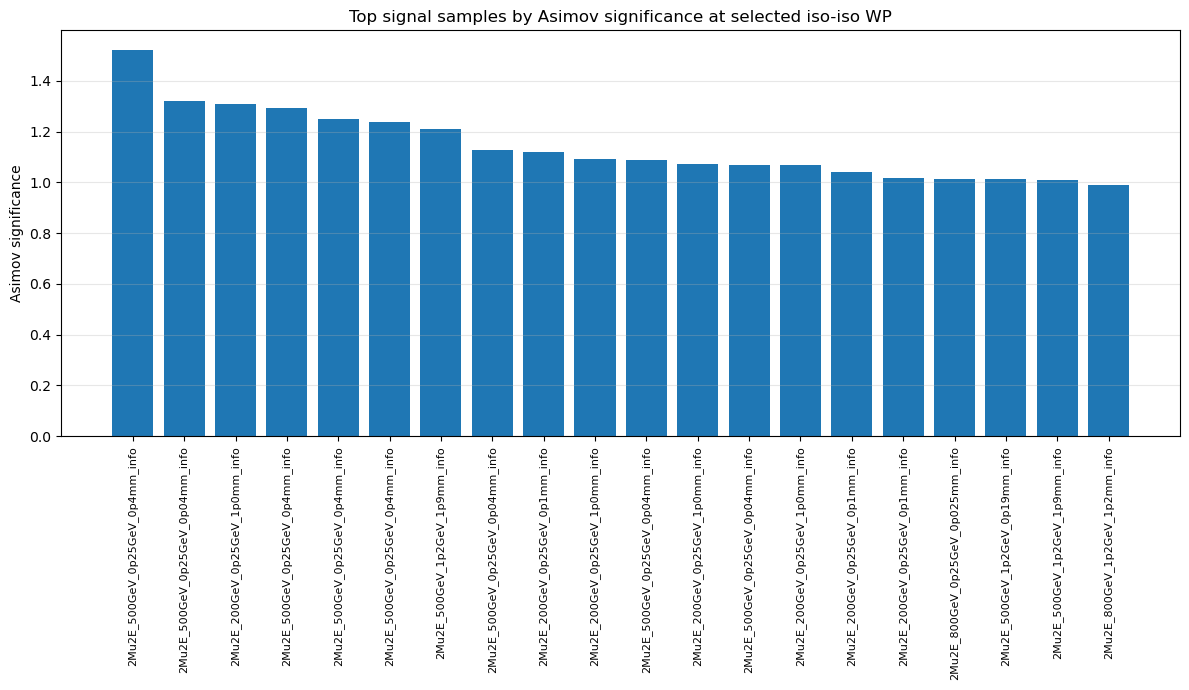

In [106]:
if sig_df is not None:
    # Guess column names
    sig_col = "AsimovSig" if "AsimovSig" in sig_df.columns else None
    name_col = "sample_name" if "sample_name" in sig_df.columns else None

    if sig_col is None:
        print("Could not find AsimovSig column.")
    else:
        top_sig = sig_df.sort_values(sig_col, ascending=False).head(20)

        display(top_sig)

        fig, ax = plt.subplots(figsize=(12, 7))

        x = np.arange(len(top_sig))
        ax.bar(x, top_sig[sig_col].to_numpy(dtype=float))

        if name_col is not None:
            ax.set_xticks(x)
            ax.set_xticklabels(top_sig[name_col].astype(str), rotation=90, fontsize=8)
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([str(i) for i in x], rotation=90, fontsize=8)

        ax.set_ylabel("Asimov significance")
        ax.set_title("Top signal samples by Asimov significance at selected iso-iso WP")
        ax.grid(True, axis="y", alpha=0.3)

        fig.tight_layout()
        fig.savefig(OUTDIR / "top20_signal_asimov.png", dpi=300)
        fig.savefig(OUTDIR / "top20_signal_asimov.pdf")
        plt.show()

In [107]:
final_summary = {
    "muIsoCut": MU_WP,
    "egmIsoCut": EGM_WP,
    "dPhiCut": DPHI_CUT,
    "mJJCut": MJJ_CUT,
    "pixelCut": PIXEL_CUT,
    "global_weighted_Pearson_corr": global_pearson,
    "global_weighted_Spearman_like_corr": global_spearman,
    "local_weighted_Pearson_corr": local_pearson,
    "local_weighted_Spearman_like_corr": local_spearman,
    "A": abcd_wp["A"],
    "A_unc": abcd_wp["A_unc"],
    "B": abcd_wp["B"],
    "B_unc": abcd_wp["B_unc"],
    "C": abcd_wp["C"],
    "C_unc": abcd_wp["C_unc"],
    "D": abcd_wp["D"],
    "D_unc": abcd_wp["D_unc"],
    "prediction": abcd_wp["prediction"],
    "prediction_unc": abcd_wp["prediction_unc"],
    "closure": abcd_wp["closure"],
    "closure_unc": abcd_wp["closure_unc"],
    "closure_significance": abcd_wp["closure_significance"],
    "tf_AC": abcd_wp["tf_AC"],
    "tf_AC_unc": abcd_wp["tf_AC_unc"],
    "tf_BD": abcd_wp["tf_BD"],
    "tf_BD_unc": abcd_wp["tf_BD_unc"],
    "tf_ratio": abcd_wp["tf_ratio"],
    "closure_central_within_pm_0p1": central_pass,
    "closure_2sigma_compatible": two_sigma_overlap,
}

final_summary_df = pd.DataFrame([final_summary])
final_summary_df.to_csv(OUTDIR / "final_isoiso_wp_summary_for_slides.csv", index=False)

final_summary_df.T

,0
muIsoCut,0.25
egmIsoCut,0.1
dPhiCut,2.0
mJJCut,150.0
pixelCut,3
global_weighted_Pearson_corr,-0.06978
global_weighted_Spearman_like_corr,-0.074383
local_weighted_Pearson_corr,-0.319232
local_weighted_Spearman_like_corr,-0.058544
A,126.930609
